In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fmin_cg

In [138]:
# Aquí convertimos las columnas de texto a números para que el modelo las entienda.
# Si hay categorías con orden (como calidad de sueño), les damos números secuenciales.
# También convertimos la columna de problemas de salud a 0 (sano) y 1 (cualquier problema).
def convertir_categoricas(df):
    if "Sleep_Quality" in df.columns:
        df["Sleep_Quality"] = df["Sleep_Quality"].map({"Poor": 0, "Fair": 1, "Good": 2, "Excellent": 3})
    
    if "Stress_Level" in df.columns:
        df["Stress_Level"]  = df["Stress_Level"].map({"Low": 0, "Medium": 1, "High": 2})
    
    if "Gender" in df.columns:
        df["Gender"]        = df["Gender"].map({"Male": 0, "Female": 1, "Other": 2})
    
    df["Health_Issues"] = df["Health_Issues"].apply(lambda x: 0 if str(x).strip() == "None" else 1)
    
    return df

In [139]:
# Normalizamos las columnas numéricas restando la media y dividiendo por la desviación estándar.
# Esto es vital para que el descenso por gradiente funcione rápido.
# Si estamos en modo test, usamos las medias que aprendimos en el entrenamiento para no hacer trampas.
def estandarizar_continuas_manual(X_df, mean_std_dict=None):
    columnas_continuas = ["Age", "Coffee_Intake", "Caffeine_mg", 
                          "Sleep_Hours", "BMI", "Heart_Rate", "Physical_Activity_Hours"]
    
    X_scaled = X_df.copy()
    
    if mean_std_dict is None:
        mean_std_dict = {}
        for col in columnas_continuas:
            if col in X_df.columns:
                mu = X_df[col].mean()
                sigma = X_df[col].std(ddof=0)
                mean_std_dict[col] = (mu, sigma)
                X_scaled[col] = (X_df[col] - mu) / (sigma + 1e-12)
    else:
        for col in columnas_continuas:
            if col in X_df.columns:
                mu, sigma = mean_std_dict[col]
                X_scaled[col] = (X_df[col] - mu) / (sigma + 1e-12)
                
    return X_scaled, mean_std_dict

In [140]:
# Dividimos nuestros datos en dos grupos: uno para entrenar y otro para testear.
# Lo hacemos manualmente barajando los índices al azar.
def holdout(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    test_len = int(len(X) * test_size)
    test_idx = indices[:test_len]
    train_idx = indices[test_len:]
    
    X_train = X.iloc[train_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)
    
    return X_train, X_test, y_train, y_test

In [141]:
# Hacemos un gráfico para ver cómo se relacionan la cafeína y el sueño con la salud.
# Pintamos los puntos en rojo si hay problemas de salud y en verde si no.
def plot_health_issues(data):
    has_issues = data[data['Health_Issues'] == 1]
    no_issues = data[data['Health_Issues'] == 0]

    plt.figure(figsize=(8,6))
    plt.scatter(no_issues['Caffeine_mg'], no_issues['Sleep_Hours'], 
                c='green', marker='o', alpha=0.6, label='No health issues')
    plt.scatter(has_issues['Caffeine_mg'], has_issues['Sleep_Hours'], 
                c='red', marker='x', alpha=0.6, label='Health issues')

    plt.xlabel("Caffeine (mg)")
    plt.ylabel("Sleep Hours")
    plt.title("Caffeine vs Sleep Hours colored by Health Issues")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [142]:
# La función sigmoide transforma cualquier número en una probabilidad entre 0 y 1
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [143]:
# Calculamos el error de nuestra predicción usando la fórmula de entropía cruzada.
# Sumamos el logaritmo de la probabilidad predicha para la clase correcta.
def coste(theta, X, y):
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    epsilon = 1e-15 
    
    term1 = np.dot(-y.T, np.log(h + epsilon))
    term2 = np.dot((1 - y).T, np.log(1 - h + epsilon))
    J = (1 / m) * (term1 - term2)
    return J

In [144]:
# Calculamos la dirección en la que debemos ajustar los pesos para reducir el error.
def gradiente(theta, X, y):
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    error = h - y
    grad = (1 / m) * np.dot(X.T, error)
    return grad

In [145]:
# Callback para registrar coste durante entrenamiento
def callback(theta):
    cost_history.append(coste(theta, X_train_bias, y_train))

In [146]:
# Hacemos predicciones con el modelo ya entrenado.
# Si bool_round es True, devolvemos 0 o 1; si no, devolvemos la probabilidad pura.
def predecir(theta, X_train, bool_round):
    m = X_train.shape[0] 
    p = np.zeros((m, 1))
    
    h = sigmoid(np.dot(X_train, theta))
    
    if bool_round:
        p = np.round(h).astype(int) 
    else:
        p = h 
        
    return p

In [147]:
# Calculamos la matriz de confusión para ver en detalle qué tal lo hemos hecho.
# Contamos cuántos aciertos y fallos hemos tenido para cada clase.
def matriz_confusion_manual(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred).flatten() 
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    print("\n--- Matriz de Confusión ---")
    print(f"{'':>15} {'Pred 0':>10} {'Pred 1':>10}")
    print(f"{'Real 0 (Sano)':>15} {tn:>10} {fp:>10}")
    print(f"{'Real 1 (Issue)':>15} {fn:>10} {tp:>10}")
    
    return tp, tn, fp, fn

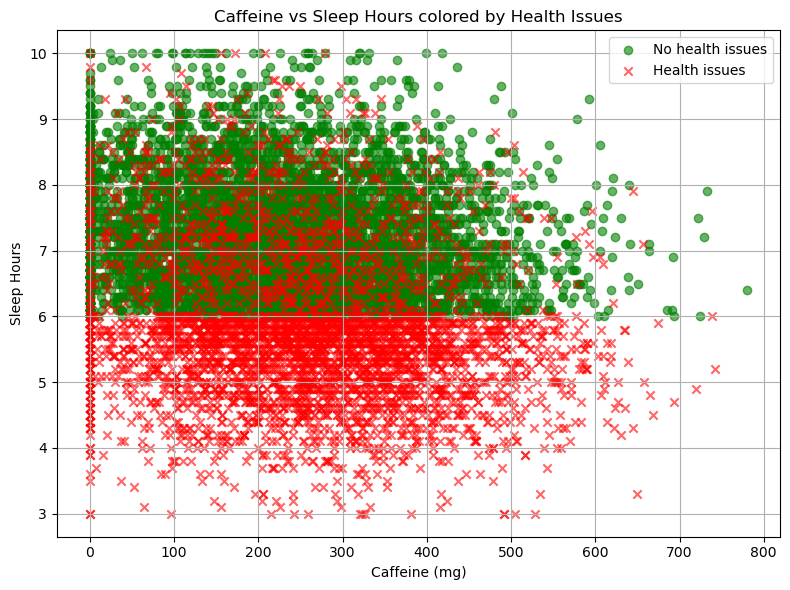


Coste inicial en TRAIN con Theta=0:  0.6931471805599433

Gradiente inicial en TRAIN con Theta=0: 
 [ 0.090375   -0.11172297  0.0454375  -0.05446397 -0.05460906  0.29441137
  0.42575    -0.07370567 -0.0092702  -0.2010625   0.00717664  0.0175
  0.0306875 ]
         Current function value: 0.165862
         Iterations: 50
         Function evaluations: 128
         Gradient evaluations: 128

Predicciones sobre TEST (primeros 10):  [1 0 0 1 1 0 0 0 1 0]
Valores reales del TEST (primeros 10):  [1 0 0 1 0 0 0 0 1 0]

Accuracy sobre TEST: 93.35%

--- Matriz de Confusión ---
                    Pred 0     Pred 1
  Real 0 (Sano)       1179         39
 Real 1 (Issue)         94        688
Accuracy sobre TRAIN: 93.10%


C:\Users\luisc\anaconda3\envs\entornoIA2425\lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


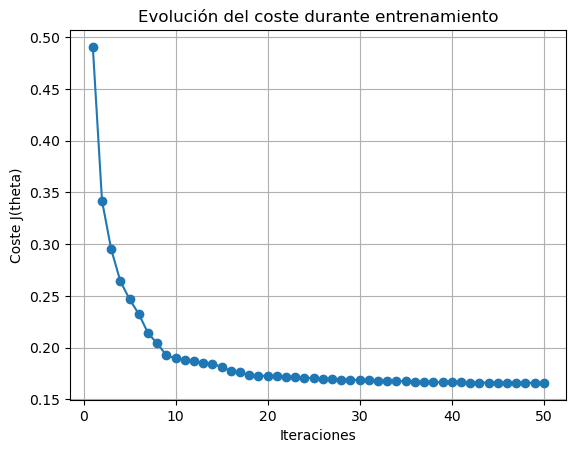


Predicción nuevo ejemplo (Café=2, Sueño=3):
 -> Clase Predicha: 0
 -> Probabilidad: 0.035290317742593384


In [148]:
# Cargamos el archivo CSV asegurándonos de que los "None" se lean como texto.
# Limpiamos las columnas que no nos sirven y separamos la variable objetivo (y) de las predictoras (X).
file = pd.read_csv("synthetic_coffee_health_10000.csv", index_col=0, keep_default_na=False)
file = file.drop(columns=["Country", "Occupation"])
file = convertir_categoricas(file)

y = file["Health_Issues"]
X = file.drop(columns=["Health_Issues"])

# Separamos los datos en entrenamiento y test antes de tocar nada más.
# Luego estandarizamos las variables numéricas, calculando la media y desviación solo con el train
# para evitar hacer trampas (data leakage).
X_train, X_test, y_train, y_test = holdout(X, y, test_size=0.2, random_state=42)

X_train_scaled, mean_std = estandarizar_continuas_manual(X_train)

X_test_scaled, _ = estandarizar_continuas_manual(X_test, mean_std)

X_train_scaled.head()

# Echamos un vistazo rápido a los datos pintando cafeína vs sueño para ver cómo se distribuyen los problemas de salud.
plot_health_issues(file)

# Añadimos la columna de "unos" (el sesgo o bias) a nuestras matrices de datos
# y hacemos una prueba inicial del coste y el gradiente con los parámetros a cero para ver que todo arranque bien.
m_train = X_train_scaled.shape[0]
X_train_bias = np.hstack([np.ones((m_train, 1)), X_train_scaled.values])

m_test = X_test_scaled.shape[0]
X_test_bias = np.hstack([np.ones((m_test, 1)), X_test_scaled.values])

n = X_train_bias.shape[1]
theta_inicial = np.zeros(n)

cost_train = coste(theta_inicial, X_train_bias, y_train)
grad_train = gradiente(theta_inicial, X_train_bias, y_train)

print("\nCoste inicial en TRAIN con Theta=0: ", cost_train)
print("\nGradiente inicial en TRAIN con Theta=0: \n", grad_train)

# Reiniciamos theta y lanzamos la optimización con fmin_cg para encontrar los mejores parámetros
# que minimicen el error de nuestro modelo.
theta_inicial = np.zeros(n)

cost_history = []

theta_opt = fmin_cg(
    f=coste,
    fprime=gradiente,
    x0=theta_inicial,
    args=(X_train_bias, y_train),
    callback=callback,
    maxiter=50
)

# Usamos los parámetros aprendidos para predecir sobre el conjunto de test.
# Calculamos qué porcentaje de aciertos tenemos y pintamos la matriz de confusión para ver dónde fallamos.
predictions_test = predict(theta_opt, X_test_bias, bool_round=True)

print("\nPredicciones sobre TEST (primeros 10): ", predictions_test.flatten()[:10])
print("Valores reales del TEST (primeros 10): ", y_test.values[:10])

accuracy_test = np.mean(predictions_test.flatten() == y_test.values) * 100
print(f"\nAccuracy sobre TEST: {accuracy_test:.2f}%")

matriz_confusion_manual(y_test, predictions_test)

# También miramos el accuracy en train para asegurarnos de que no hay sobreajuste.
predictions_train = predict(theta_opt, X_train_bias, bool_round=True)
accuracy_train = np.mean(predictions_train.flatten() == y_train.values) * 100
print(f"Accuracy sobre TRAIN: {accuracy_train:.2f}%")

# Gráfica de convergencia
# Pintamos cómo ha bajado el coste iteración a iteración para confirmar que el entrenamiento ha funcionado.
plt.figure()
plt.plot(range(1, len(cost_history)+1), cost_history, marker='o')
plt.xlabel("Iteraciones")
plt.ylabel("Coste J(theta)")
plt.title("Evolución del coste durante entrenamiento")
plt.grid(True)
plt.show()

# Creamos un paciente hipotético con mucho café y poco sueño, estandarizamos sus datos
# y le preguntamos al modelo si cree que tendrá problemas de salud.
x_new = np.zeros(X_train.shape[1], dtype=float)  

for i, col in enumerate(X_train.columns):
    if col in mean_std:  
        mean, std = mean_std[col]
        x_new[i] = mean  
    else:  
        x_new[i] = X_train[col].mode()[0]  

# Modificar solo las que nos interesan
idx_coffee = list(X_train.columns).index("Coffee_Intake")
idx_sleep = list(X_train.columns).index("Sleep_Hours")
x_new[idx_coffee] = 2
x_new[idx_sleep] = 3

# Estandarizar columnas continuas
for i, col in enumerate(X_train.columns):
    if col in mean_std:
        mean, std = mean_std[col]
        x_new[i] = (x_new[i] - mean) / std

# Añadir bias
x_new_bias = np.hstack([1, x_new]).reshape(1, -1)

# Predicción
pred_binaria = predict(theta_opt, x_new_bias, bool_round=True)[0]
pred_prob = predict(theta_opt, x_new_bias, bool_round=False)[0] 

print(f"\nPredicción nuevo ejemplo (Café=2, Sueño=3):")
print(f" -> Clase Predicha: {int(pred_binaria)}")
print(f" -> Probabilidad: {pred_prob}")